In [1]:
import plotly.io as pio
pio.renderers.default = "png"


In [2]:
from dsc80_utils import *
import lec16_util as util

# Lecture 16 – Pipelines, Multicollinearity, and Generalization

## DSC 80, Summer 2026

### Agenda 📆

- Review: transformers.
- Pipelines.
- Multicollinearity.
- Generalization.
    - Bias and variance.
    - Train-test splits.

## Review: transformers

### Transformer classes

- **Transformers** take in "raw" data and output "processed" data. They are used for **creating features**.

- The input to a transformer should be a multi-dimensional `numpy` array.
    - Inputs can be DataFrames, but `sklearn` only looks at the values (i.e. it calls `to_numpy()` on input DataFrames).

- The output of a transformer is a `numpy` array (never a DataFrame or Series).

- Transformers, like most relevant features of `sklearn`, are **classes**, not functions, meaning you need to instantiate them and call their methods.

### Example: Predicting tips 🧑‍🍳

Let's return to our trusty `tips` dataset.

In [3]:
tips = px.data.tips()
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Example transformer: `Binarizer`

The `Binarizer` transformer allows us to map a quantitative sequence to a sequence of 1s and 0s, depending on whether values are above or below a threshold.

|Property|Example|Description|
|---|---|---|
|Initialize with parameters| `binar = Binarizer(thresh)` | Set x=1 if x > thresh, else set x=0|
|Transform data in a dataset | `feat = binar.transform(data)` | Binarize all columns in `data`|

In [4]:
from sklearn.preprocessing import Binarizer
bi = Binarizer(threshold=20)

In [5]:
transformed_bills = bi.transform(tips[['total_bill']].to_numpy()) 
transformed_bills[:5]

array([[0.],
       [0.],
       [1.],
       [1.],
       [1.]])

### Example transformer: `StandardScaler`

- `StandardScaler` **standardizes** data using the mean and standard deviation of the data.

$$z(x_i) = \frac{x_i - \text{mean of } x}{\text{SD of } x}$$

- Unlike `Binarizer`, `StandardScaler` **requires some knowledge (mean and SD) of the dataset before transforming**.

- As such, we need to **`fit`** a `StandardScaler` transformer before we can use the `transform` method.

- Typical usage: fit transformer on a sample, use that fit transformer to transform future data.

### Example transformer: `StandardScaler`

It only makes sense to standardize the already-quantitative features of `tips`, so let's select just those.

In [6]:
tips_quant = tips[['total_bill', 'size']]
tips_quant.head()

,total_bill,size
0,16.99,2
1,10.34,3
2,21.01,3
3,23.68,2
4,24.59,4


In [7]:
from sklearn.preprocessing import StandardScaler
stdscaler = StandardScaler()

In [8]:
# This is like saying "determine the mean and SD of each column in tips_quant".
stdscaler.fit(tips_quant)

StandardScaler()

In [9]:
# First column is 'total_bill', second column is 'size'.
tips_quant_z = stdscaler.transform(tips_quant)
tips_quant_z[:5]

array([[-0.31, -0.6 ],
       [-1.06,  0.45],
       [ 0.14,  0.45],
       [ 0.44, -0.6 ],
       [ 0.54,  1.51]])

We can also access the mean and variance that `stdscaler` computed for each column:

In [10]:
stdscaler.mean_

array([19.79,  2.57])

In [11]:
stdscaler.var_

array([78.93,  0.9 ])

Note that we can call `transform` on DataFrames other than `tips_quant`. We will do this often – fit a transformer on one dataset (training data) and use it to transform other datasets (test data).

In [12]:
stdscaler.transform(tips_quant.sample(5))

array([[-1.04, -0.6 ],
       [ 1.63,  3.61],
       [-0.73, -0.6 ],
       [-0.49, -0.6 ],
       [-0.72, -0.6 ]])

### 💡 Pro-Tip: Using `.fit_transform`

The `.fit_transform` method will fit the transformer and then transform the data in one go.

In [13]:
stdscaler.fit_transform(tips_quant)

array([[-0.31, -0.6 ],
       [-1.06,  0.45],
       [ 0.14,  0.45],
       ...,
       [ 0.32, -0.6 ],
       [-0.22, -0.6 ],
       [-0.11, -0.6 ]])

### `StandardScaler` summary

|Property|Example|Description|
|---|---|---|
|Initialize with parameters| `stdscaler = StandardScaler()` | z-score the data (no parameters) |
|Fit the transformer| `stdscaler.fit(X)` | Compute the mean and SD of `X`|
|Transform data in a dataset | `feat = stdscaler.transform(X_new)` | z-score `X_new` using mean and SD of `X`|
|Fit and transform| `stdscaler.fit_transform(X)` | Compute the mean and SD of `X`, then z-score `X`|

### Example transformer: `OneHotEncoder`

Let's keep just the categorical columns in `tips`.

In [14]:
tips_cat = tips[['sex', 'smoker', 'day', 'time']]
tips_cat.head()

,sex,smoker,day,time
0,Female,No,Sun,Dinner
1,Male,No,Sun,Dinner
2,Male,No,Sun,Dinner
3,Male,No,Sun,Dinner
4,Female,No,Sun,Dinner


Like `StandardScaler`, we will need to `fit` our `OneHotEncoder` transformer before it can transform anything.

In [15]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
ohe.fit(tips_cat)

OneHotEncoder()

When we try to transform, we get a result we might not expect.

In [16]:
ohe.transform(tips_cat)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 976 stored elements and shape (244, 10)>

Since the resulting matrix is **sparse** – most of its elements are 0 – `sklearn` uses a more efficient representation than a regular `numpy` array. We can convert to a regular (dense) array:

In [17]:
ohe.transform(tips_cat).toarray()

array([[1., 0., 1., ..., 0., 1., 0.],
       [0., 1., 1., ..., 0., 1., 0.],
       [0., 1., 1., ..., 0., 1., 0.],
       ...,
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 1., ..., 0., 1., 0.],
       [1., 0., 1., ..., 1., 1., 0.]])

Notice that the column names from `tips_cat` are no longer stored anywhere (remember, `fit` converts the input to a `numpy` array before proceeding). This makes it hard to interpret the meaning of the 1's and 0's in the array.

We can use the `get_feature_names_out` method on `ohe` to access the names of the one-hot-encoded columns:

In [18]:
ohe.get_feature_names_out() 

array(['sex_Female', 'sex_Male', 'smoker_No', 'smoker_Yes', 'day_Fri',
       'day_Sat', 'day_Sun', 'day_Thur', 'time_Dinner', 'time_Lunch'],
      dtype=object)

In [19]:
pd.DataFrame(ohe.transform(tips_cat).toarray(), 
             columns=ohe.get_feature_names_out()) 

,sex_Female,sex_Male,smoker_No,smoker_Yes,...,day_Sun,day_Thur,time_Dinner,time_Lunch
0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0
1,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0
2,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
241,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0
242,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0
243,1.0,0.0,1.0,0.0,...,0.0,1.0,1.0,0.0


### Example transformer: `FunctionTransformer`

A `FunctionTransformer` enables you to use your own functions on entire columns. Think of it as the `sklearn` equivalent of `apply`.

In [20]:
from sklearn.preprocessing import FunctionTransformer
f = FunctionTransformer(np.sqrt)
f.transform([1, 2, 3])

array([1.  , 1.41, 1.73])

In [21]:
# Same result, using numpy only.
np.sqrt([1, 2, 3])

array([1.  , 1.41, 1.73])

We didn't really need `sklearn` for that! But using `FunctionTransformer` allows us to easily incorporate this step with other `sklearn` encoding steps. 

## Pipelines

<center><img src="imgs/image_0.png" width="50%"></center>

<br>

So far, we've used transformers for feature engineering and models for prediction. We can combine these steps into a single `Pipeline`.

### `Pipeline`s in `sklearn`

 -  Pipeline allows you to sequentially apply a list of transformers to preprocess the data and, **if desired**, conclude the sequence with a final predictor for predictive modeling.

- General template: `pl = Pipeline([trans_1, trans_2, ..., model])`
    - Note that the `model` is optional.

- Once a `Pipeline` is instantiated, you can fit **all** steps (transformers and model) using `pl.fit(X, y)`.

- To make predictions using **raw, untransformed data**, use `pl.predict(X)`.

- `Pipeline` takes as input a **list of 2-tuples**, where:
    - The first element is a "name" that we choose for the step. It can be anything!
    - The second element is an instance of a transformer or estimator (model) class.

### Our first `Pipeline`

Let's build a `Pipeline` that:
- One hot encodes the categorical features in `tips`.
- Fits a regression model on the one hot encoded data.

In [22]:
# Start with categorical features only.
tips_cat.head()

,sex,smoker,day,time
0,Female,No,Sun,Dinner
1,Male,No,Sun,Dinner
2,Male,No,Sun,Dinner
3,Male,No,Sun,Dinner
4,Female,No,Sun,Dinner


In [23]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pl = Pipeline([
    ('one-hot', OneHotEncoder()),
    ('lin-reg', LinearRegression())
])

Now that `pl` is instantiated, we `fit` it the same way we would fit the individual steps.

In [24]:
pl.fit(tips_cat, tips['tip'])

Pipeline(steps=[('one-hot', OneHotEncoder()), ('lin-reg', LinearRegression())])

Now, to make predictions using **raw data**, all we need to do is use `pl.predict`:

In [25]:
pl.predict(tips_cat.iloc[:5])

array([3.1 , 3.27, 3.27, 3.27, 3.1 ])

`pl` performs **both** feature transformation and prediction with just a single call to `predict`!

We can access individual "steps" of a `Pipeline` through the `named_steps` attribute:

In [26]:
pl.named_steps

{'one-hot': OneHotEncoder(), 'lin-reg': LinearRegression()}

In [27]:
pl.named_steps['one-hot'].transform(tips_cat).toarray()

array([[1., 0., 1., ..., 0., 1., 0.],
       [0., 1., 1., ..., 0., 1., 0.],
       [0., 1., 1., ..., 0., 1., 0.],
       ...,
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 1., ..., 0., 1., 0.],
       [1., 0., 1., ..., 1., 1., 0.]])

In [28]:
pl.named_steps['one-hot'].get_feature_names_out()

array(['sex_Female', 'sex_Male', 'smoker_No', 'smoker_Yes', 'day_Fri',
       'day_Sat', 'day_Sun', 'day_Thur', 'time_Dinner', 'time_Lunch'],
      dtype=object)

In [29]:
pl.named_steps['lin-reg'].coef_

array([-0.09,  0.09, -0.04,  0.04, -0.2 , -0.13,  0.14,  0.19,  0.25,
       -0.25])

`pl` also has a `score` method, the same way a fit `LinearRegression` instance does:

In [30]:
# Why is this so low?
pl.score(tips_cat, tips['tip'])

0.027496790201475663

### More sophisticated `Pipeline`s

- In the previous example, we one hot encoded every input column. **What if we want to perform different transformations on different columns?**

- **Solution**: Use a `ColumnTransformer`.
    - Instantiate a `ColumnTransformer` using a **list of 3-tuples**, where:
        - The first element is a "name" that we choose for the transformer. It can be anything!
        - The second element is a transformer instance (e.g. `OneHotEncoder()`).
        - The third element is a **list of relevant column names**.

### Planning our first `ColumnTransformer`

In [31]:
from sklearn.compose import ColumnTransformer

Let's perform different transformations on the quantitative and categorical features of `tips` (note that we are not transforming the response variable, `'tip'`).

In [32]:
tips_features = tips.drop('tip', axis=1)
tips_features.head()

,total_bill,sex,smoker,day,time,size
0,16.99,Female,No,Sun,Dinner,2
1,10.34,Male,No,Sun,Dinner,3
2,21.01,Male,No,Sun,Dinner,3
3,23.68,Male,No,Sun,Dinner,2
4,24.59,Female,No,Sun,Dinner,4


- We will leave the `'total_bill'` column untouched.

- To the `'size'` column, we will apply the `Binarizer` transformer with a threshold of 2 (big tables vs. small tables).

- To the categorical columns, we will apply the `OneHotEncoder` transformer.


- In essence, we will create a transformer that reproduces the following DataFrame:

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>size</th>
      <th>sex_Female</th>
      <th>sex_Male</th>
      <th>smoker_No</th>
      <th>smoker_Yes</th>
      <th>day_Fri</th>
      <th>day_Sat</th>
      <th>day_Sun</th>
      <th>day_Thur</th>
      <th>time_Dinner</th>
      <th>time_Lunch</th>
      <th>total_bill</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>0</td>
      <td>1.0</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>0.0</td>
      <td>16.99</td>
    </tr>
    <tr>
      <th>1</th>
      <td>1</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>1.0</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>0.0</td>
      <td>10.34</td>
    </tr>
    <tr>
      <th>2</th>
      <td>1</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>1.0</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>0.0</td>
      <td>21.01</td>
    </tr>
    <tr>
      <th>3</th>
      <td>0</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>1.0</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>0.0</td>
      <td>23.68</td>
    </tr>
    <tr>
      <th>4</th>
      <td>1</td>
      <td>1.0</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>0.0</td>
      <td>1.0</td>
      <td>0.0</td>
      <td>24.59</td>
    </tr>
  </tbody>
</table>


### Building a `Pipeline` using a `ColumnTransformer`

Let's start by creating our `ColumnTransformer`.

In [33]:
preproc = ColumnTransformer(
    transformers=[
        ('size', Binarizer(threshold=2), ['size']),
        ('categorical_cols', OneHotEncoder(), ['sex', 'smoker', 'day', 'time'])
    ],
    # Specify what to do with all other columns ('total_bill' here).
    # Options are 'drop' or 'passthrough'.
    remainder='passthrough',
    # Keep original data types for remaining columns.
    force_int_remainder_cols=False
)

Now, let's create a `Pipeline` using `preproc` as a transformer, and `fit` it:

In [34]:
pl = Pipeline([
    ('preprocessor', preproc), 
    ('lin-reg', LinearRegression())
])

In [35]:
pl.fit(tips_features, tips['tip'])

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('size',
                                                  Binarizer(threshold=2),
                                                  ['size']),
                                                 ('categorical_cols',
                                                  OneHotEncoder(),
                                                  ['sex', 'smoker', 'day',
                                                   'time'])])),
                ('lin-reg', LinearRegression())])

Prediction is as easy as calling `predict`:

In [36]:
tips_features.head()

,total_bill,sex,smoker,day,time,size
0,16.99,Female,No,Sun,Dinner,2
1,10.34,Male,No,Sun,Dinner,3
2,21.01,Male,No,Sun,Dinner,3
3,23.68,Male,No,Sun,Dinner,2
4,24.59,Female,No,Sun,Dinner,4


In [37]:
# Note that we fit the Pipeline using tips_features, not tips_features.head()!
pl.predict(tips_features.head())

array([2.74, 2.32, 3.37, 3.37, 3.75])

### 💡 Pro-Tip: Using `make_pipeline` and `make_column_transformer`

Instead of using `Pipeline` and `ColumnTransformer` classes directly, `sklearn` provides shortcut methods `make_pipeline` and `make_column_transformer`. These methods are less verbose than using the constructors, as they determine the names of steps for you automatically.

In [38]:
# Old code

preproc = ColumnTransformer(
    transformers=[
        ('size', Binarizer(threshold=2), ['size']),
        ('categorical_cols', OneHotEncoder(), ['sex', 'smoker', 'day', 'time'])
    ],
    remainder='passthrough',
    force_int_remainder_cols=False
)

pl = Pipeline([
    ('preprocessor', preproc), 
    ('lin-reg', LinearRegression())
])
pl

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('size',
                                                  Binarizer(threshold=2),
                                                  ['size']),
                                                 ('categorical_cols',
                                                  OneHotEncoder(),
                                                  ['sex', 'smoker', 'day',
                                                   'time'])])),
                ('lin-reg', LinearRegression())])

In [39]:
# New code

from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

preproc = make_column_transformer(
    (Binarizer(threshold=2), ['size']),
    (OneHotEncoder(), ['sex', 'smoker', 'day', 'time']),
    remainder='passthrough',
)

pl = make_pipeline(preproc, LinearRegression())
# Notice that the steps are automatically named
pl

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('binarizer',
                                                  Binarizer(threshold=2),
                                                  ['size']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(),
                                                  ['sex', 'smoker', 'day',
                                                   'time'])])),
                ('linearregression', LinearRegression())])

### An example `Pipeline`

Let's build a `Pipeline` that:
- Takes in the `'total_bill'` and `'size'` features of `tips`.
- Standardizes those features.
- Uses the resulting standardized features to fit a linear model that predicts `'tip'`.

In [40]:
# Let's define these once, since we'll use them repeatedly.
X = tips[['total_bill', 'size']]
y = tips['tip']

In [41]:
from sklearn.preprocessing import StandardScaler

model_su = make_pipeline(
    StandardScaler(),
    LinearRegression(),
)

model_su.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])

How well does our model do? We can compute its $R^2$ and RMSE.

In [42]:
model_su.score(X, y)

0.46786930879612587

In [43]:
from sklearn.metrics import root_mean_squared_error

root_mean_squared_error(y, model_su.predict(X))

1.007256127114662

Does this model perform any better than one that _doesn't_ standardize its features? Let's find out.

In [44]:
model_orig = LinearRegression()
model_orig.fit(X, y)

LinearRegression()

In [45]:
model_orig.score(X, y)

0.46786930879612587

In [46]:
root_mean_squared_error(y, model_orig.predict(X))

1.007256127114662

**No!**

### The purpose of standardizing features

- For linear regression, standardizing your features **will not** change your model's error.

- There are other models where standardizing your features _will_ improve performance, or where the model requires features to be standardized.
    - Regularized linear regression (see [DSC 140A](https://dsc140a.com)).
    - PCA (assumes centered data, not necessarily standardized: see [DSC 140B](https://dsc140b.com)).
    - Clustering algorithms, e.g. $k$-means clustering (saw in DSC 40A).

- There _is_ a benefit to standardizing features when performing linear regression, as we saw in DSC 40A: the features are brought to the same scale, so the coefficients can be compared directly.

In [47]:
# Total bill, table size.
model_orig.coef_

array([0.09, 0.19])

In [48]:
# Standardized total bill, standardized table size.
model_su.named_steps['linearregression'].coef_

array([0.82, 0.18])

## Multicollinearity

### Heights and weights

We have a dataset containing the weights and heights of 25,000 18 year olds.

In [49]:
people_path = Path('data') / 'SOCR-HeightWeight.csv'
people = pd.read_csv(people_path).drop(columns=['Index'])
people.head()

,Height (Inches),Weight (Pounds)
0,65.78,112.99
1,71.52,136.49
2,69.40,153.03
3,68.22,142.34
4,67.79,144.30


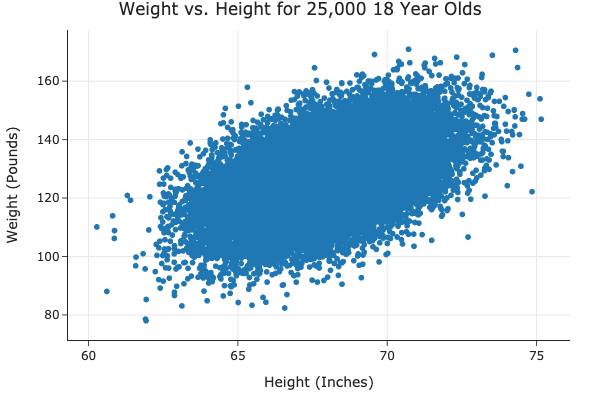

In [50]:
people.plot(kind='scatter', x='Height (Inches)', y='Weight (Pounds)', 
            title='Weight vs. Height for 25,000 18 Year Olds')

### Motivating example

Suppose we fit a simple linear regression model that uses **height in inches** to predict **weight in pounds**.

$$\text{predicted weight (pounds)} = w_0 + w_1 \cdot \text{height (inches)}$$

In [51]:
X = people[['Height (Inches)']]
y = people['Weight (Pounds)']

In [52]:
lr_one_feat = LinearRegression()
lr_one_feat.fit(X, y)

LinearRegression()

$w_0^*$ and $w_1^*$ are shown below, along with the model's training set RMSE.

In [53]:
lr_one_feat.intercept_, lr_one_feat.coef_

(-82.57574306454093, array([3.08]))

In [54]:
root_mean_squared_error(y, lr_one_feat.predict(X))

10.079113675632819

Now, suppose we fit another regression model, that uses **height in inches** AND **height in centimeters** to predict weight.

$$\text{predicted weight (pounds)} = w_0 + w_1 \cdot \text{height (inches)} + w_2 \cdot \text{height (cm)}$$

In [55]:
people['Height (cm)'] = people['Height (Inches)'] * 2.54 # 1 inch = 2.54 cm

In [56]:
X2 = people[['Height (Inches)', 'Height (cm)']]

In [57]:
lr_two_feat = LinearRegression()
lr_two_feat.fit(X2, y)

LinearRegression()

What are $w_0^*$, $w_1^*$, $w_2^*$, and the model's test RMSE?

In [58]:
lr_two_feat.intercept_, lr_two_feat.coef_

(-82.57585227669999, array([ 3.38e+10, -1.33e+10]))

In [59]:
root_mean_squared_error(y, lr_two_feat.predict(X2))

10.079113516358378

**Observation**: The intercept is about the same as before, as is the RMSE. However, the coefficients on `'Height (Inches)'` and `'Height (cm)'` are massive in size!

What's going on?

### Redundant features

Let's use simpler numbers for illustration. Suppose in the first model, $w_0^* = -82$ and $w_1^* = 3$.

$$\text{predicted weight (pounds)} = -82 + 3 \cdot \text{height (inches)}$$

In the second model, we have:

$$\begin{align*}\text{predicted weight (pounds)} &= w_0^* + w_1^* \cdot \text{height (inches)} + w_2^* \cdot \text{height (cm)} \\ &= w_0^* + w_1^* \cdot \text{height (inches)} + w_2^* \cdot \big( 2.54 \cdot \text{height (inches)} \big) \\ &= w_0^* + \left(w_1^* + 2.54 \cdot w_2^* \right) \cdot \text{height (inches)} \end{align*}$$

In the first model, we already found the "best" intercept ($-82$) and slope ($3$) in a linear model that uses height in inches to predict weight.

**So, as long as $w_1^* + 2.54 \cdot w_2^* = 3$ in the second model, the second model's training predictions will be the same as the first, and hence they will also minimize RMSE.**

### Infinitely many parameter choices

**Issue**: There are an infinite number of $w_1^*$ and $w_2^*$ that satisfy $w_1^* + 2.54 \cdot w_2^* = 3$!

$$\text{predicted weight} = -82 - 10 \cdot \text{height (inches)} + \frac{13}{2.54} \cdot \text{height (cm)}$$

$$\text{predicted weight} = -82 + 10 \cdot \text{height (inches)} - \frac{7}{2.54} \cdot \text{height (cm)}$$

In [60]:
(-82 - 10 * people.iloc[:, 0] + (13 / 2.54) * people.iloc[:, 2]).head()

0    115.35
1    132.55
2    126.20
3    122.65
4    121.36
dtype: float64

In [61]:
(-82 + 10 * people.iloc[:, 0] - (7 / 2.54) * people.iloc[:, 2]).head()

0    115.35
1    132.55
2    126.20
3    122.65
4    121.36
dtype: float64

- Both prediction rules look very different, but actually make the same predictions.


- We might get either set of coefficients, or any other of the infinitely many options. 


- But neither set of coefficients **has any meaning!**

### Multicollinearity

- Multicollinearity occurs when features in a regression model are **highly correlated** with one another.
    - In other words, multicollinearity occurs when **a feature can be predicted using a linear combination of other features, fairly accurately**.

- When multicollinearity is present in the features, the **coefficients in the model** are uninterpretable – they have no meaning.
    - A "slope" represents "the rate of change of $y$ with respect to a feature", when all other features are held constant – but if there's multicollinearity, you can't hold other features constant.

- **Note: Multicollinearity doesn't impact a model's predictions!**
    - It doesn't impact a model's ability to generalize to unseen data.
    - If features are multicollinear in the training data, they will probably be multicollinear in the test data too.

- **Solutions**:
    - Manually remove highly correlated features.
    - Use a dimensionality reduction technique (such as PCA) to automatically reduce dimensions.

### Example: One hot encoding

**A one hot encoding will result in multicollinearity unless you drop one of the one hot encoded features.**

Suppose we have the following fitted model:

$$
\begin{aligned}
H(x) = 1 + 2 \cdot (\text{smoker==Yes}) - 2 \cdot (\text{smoker==No})
\end{aligned}
$$

This is equivalent to:

$$
\begin{aligned}
H(x) = 10 - 7 \cdot (\text{smoker==Yes}) - 11 \cdot (\text{smoker==No})
\end{aligned}
$$

Solution: Drop one of the one hot encoded columns. The `OneHotEncoder` transformer has an option to do this.

### Example: `Pipeline`s within `Pipeline`s

Suppose we want to:
- One hot encode the `'day'` column, but as either `'Weekday'`, `'Sat'`, or `'Sun'`.
- One hot encode the `'sex'`, `'smoker'`, and `'time'` columns.
- Binarize the `'size'` column with a threshold of 2.
- Leave the `'total_bill'` column alone.
- Fit a linear regression model using only non-redundant features.

Here's how we might do that:

In [62]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
...,...,...,...,...,...,...,...
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


If you want to apply multiple transformations to the same column in a dataset, you can create a `Pipeline` just for that column.

In [63]:
def is_weekend(s):
    # The input to is_weekend is a Series!
    return s.replace({'Thur': 'Weekday', 'Fri': 'Weekday'})

In [64]:
pl_day = make_pipeline(
    FunctionTransformer(is_weekend),
    OneHotEncoder(drop='first'),
)

To do separate transformations for different columns, we use a `ColumnTransformer`. For the `'day'` column, instead of specifying a transformer class, we use `pl_day`, the `Pipeline` we just created.

In [65]:
col_trans = make_column_transformer(
    (pl_day, ['day']),
    (OneHotEncoder(drop='first'), ['sex', 'smoker', 'time']),
    (Binarizer(threshold=2), ['size']),
    remainder='passthrough',
    force_int_remainder_cols=False
)

In [66]:
pl = make_pipeline(
    col_trans,
    LinearRegression(),
)

pl.fit(tips.drop('tip', axis=1), tips['tip'])

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('pipeline',
                                                  Pipeline(steps=[('functiontransformer',
                                                                   FunctionTransformer(func=<function is_weekend at 0x305419d00>)),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['day']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker', 'time']),
                                                 ('binarizer',
                                                  Binarizer(threshold=2),
                                                  ['size'])])),
                ('linearregression', LinearRegression())])

<div class="alert alert-warning">
    <h3>Question</h3>
</div>

How many weights does this linear model have?

In [67]:
# pl.named_steps['linearregression'].coef_.shape[0]

### Key takeaways

- Multicollinearity is present in a linear model when one feature can be accurately predicted using one or more other features.
    - In other words, it is present when a feature is **redundant**.

- Multicollinearity doesn't pose an issue for prediction; it doesn't hinder a model's ability to generalize. Instead, it renders the **coefficients** of a linear model meaningless.

## Generalization

### Motivation

- You and your friend are studying for an upcoming exam. You both decide to test your understanding by taking a **practice exam**.
    - Your logic: If you do well on the practice exam, you should do well on the real exam.

- You each take the practice exam once and look at the solutions afterwards.

- **Your strategy**: Memorize the answers to all practice exam questions, e.g. "Question 1: A; Question 2: C; Question 3: A."

- **Your friend's strategy**: Learn high-level concepts from the solutions, e.g. "data are MNAR if the likelihood of missingness depends on the missing values themselves."

- Who will do better on the **practice exam**? Who will probably do better on the **real exam**? 🧐

### Evaluating the quality of a model

- So far, we've computed the RMSE (and $R^2$) of our fit regression models on the **data that we used to fit them**, i.e. the **training data**.

- We've said that Model A is **better** than Model B if Model A's RMSE is **lower** than Model B's RMSE.
    - Remember, our **training data** is a sample from some population.
    - Just because a model fits the training data well doesn't mean it will **generalize** and work well on **similar, unseen samples** from the same population!

### Example: Overfitting and underfitting

Let's collect two samples $\{(x_i, y_i)\}$ from the same population.

In [68]:
np.random.seed(23) # For reproducibility.

def sample_from_pop(n=100):
    x = np.linspace(-2, 3, n)
    y = x ** 3 + (np.random.normal(0, 3, size=n))
    return pd.DataFrame({'x': x, 'y': y})

sample_1 = sample_from_pop()
sample_2 = sample_from_pop()

For now, let's just look at Sample 1. The relationship between $x$ and $y$ is roughly **cubic**; that is, $y \approx x^3$ (remember, in reality, you won't get to see the population).

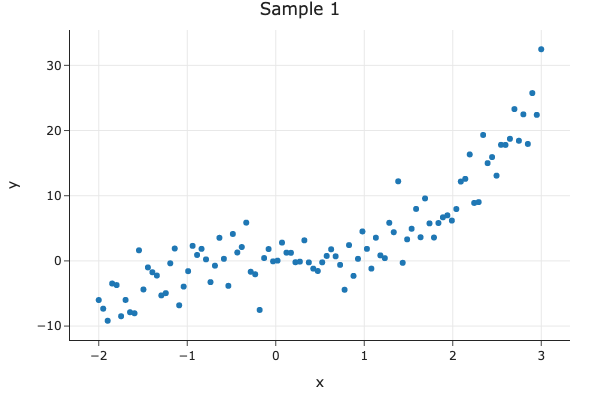

In [69]:
px.scatter(sample_1, x='x', y='y', title='Sample 1')

### Polynomial regression

Let's fit three **polynomial** models on Sample 1:
- Degree 1.
- Degree 3.
- Degree 25.

The `PolynomialFeatures` transformer will be helpful here.

In [70]:
from sklearn.preprocessing import PolynomialFeatures
d2 = PolynomialFeatures(3)
d2.fit_transform(np.array([1, 2, 3, 4, -2]).reshape(5, 1))

array([[ 1.,  1.,  1.,  1.],
       [ 1.,  2.,  4.,  8.],
       [ 1.,  3.,  9., 27.],
       [ 1.,  4., 16., 64.],
       [ 1., -2.,  4., -8.]])

Below, we look at our three models' predictions on Sample 1 (which they were trained on).

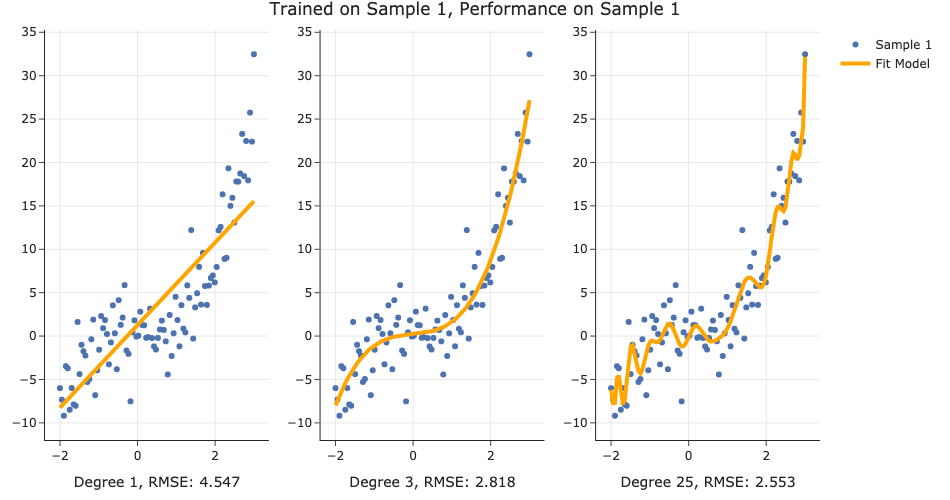

In [71]:
# Look at the definition of train_and_plot in lec15_util.py if you're curious as to how the plotting works.
fig = util.train_and_plot(train_sample=sample_1, test_sample=sample_1, degs=[1, 3, 25], data_name='Sample 1')
fig.update_layout(title='Trained on Sample 1, Performance on Sample 1')

The degree 25 polynomial has the lowest RMSE on Sample 1.

How do the same fit polynomials look on Sample 2?

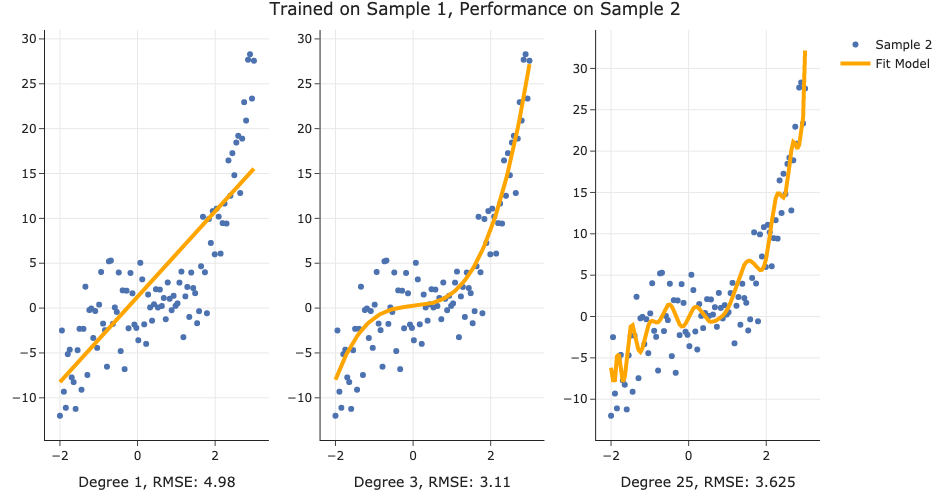

In [72]:
fig = util.train_and_plot(train_sample=sample_1, test_sample=sample_2, degs=[1, 3, 25], data_name='Sample 2')
fig.update_layout(title='Trained on Sample 1, Performance on Sample 2')

- The degree 3 polynomial has the lowest RMSE on Sample 2. 

- Note that **we didn't get to see Sample 2 when fitting our models**! 

- As such, it seems that the degree 3 polynomial **generalizes better** to unseen data than the degree 25 polynomial does.

What if we fit a degree 1, degree 3, and degree 25 polynomial **on Sample 2** as well?

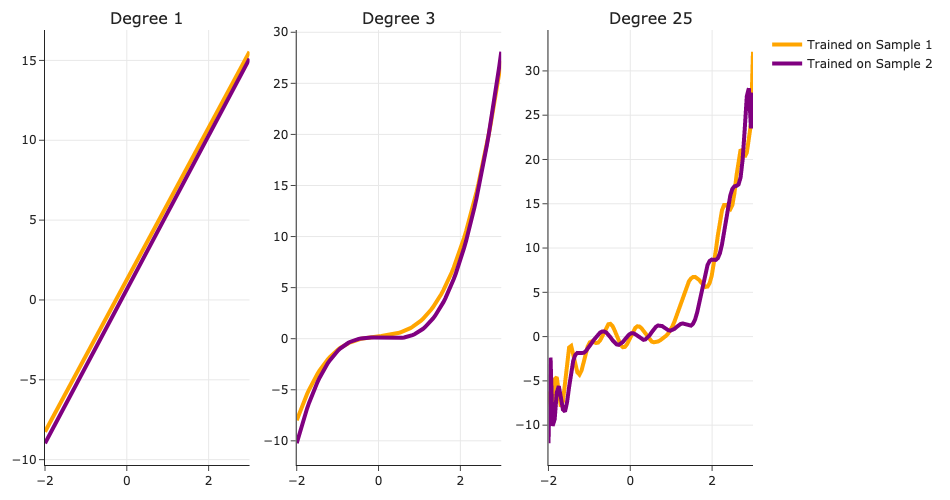

In [73]:
util.plot_multiple_models(sample_1, sample_2, degs=[1, 3, 25])

**Key idea**: Degree 25 polynomials seem to **vary more when trained on different samples** than degree 3 and 1 polynomials do.

### Bias and variance

The training data we have access to is a sample from the population. We are concerned with our model's ability to **generalize** and work well on **different datasets** drawn from the same population.

Suppose we **fit** a model $H$ (e.g. a degree 3 polynomial) on **several different datasets** from the same population. There are three sources of error that arise:

* ⭐️ **Bias**: **The expected deviation between a predicted value and an actual value**.
    - In other words, **for a given $x_i$, how far is $H(x_i)$ from the true $y_i$, on average?**
    - Low bias is good! ✅
    - High bias is a sign of **underfitting**, i.e. that our model is too **basic** to capture the relationship between our features and response.

- ⭐️ **Model variance ("variance")**: **The variance of a model's predictions**.
    - In other words, **for a given $x_i$, how much does $H(x_i)$ vary across all datasets**?
    - Low model variance is good! ✅
    - High model variance is a sign of **overfitting**, i.e. that our model is too **complicated** and is prone to fitting to the noise in our training data.

- **Observation error**: The error due to the random noise in the process we are trying to model (e.g. measurement error). _We can't control this, without collecting more data!_

Here, suppose:
- The <span style='color:#c6283f'><b>red bulls-eye</b></span> represents an **actual tip** 💲.
- The <span style='color:#080c6f'><b>dark blue darts</b></span> represent **predictions of the tip** using different models that were fit on samples from the same data generating process. 
<br>

<center><img src="imgs/image_5.png" width="40%"></center>

We'd like our models to be in the top left, but in practice that's hard to achieve!

### Risk vs. empirical risk

- **Key idea**: A model that works well on past data should work well on future data, if future data looks like past data.

- What we really want is for the **expected loss for a new data point $(x_{\text{new}}, y_{\text{new}})$, drawn from the same population as the training set, to be small**. That is, we want
    $$\mathbb{E}[y_{\text{new}} - H(x_{\text{new}})]^2$$
    to be minimized. The quantity above is called **risk**.

- $\mathbb{E}$ is the **expectation** operator of a random variable: it computes the **average value** of the random variable across its entire distribution.

- In general, we don't know the entire population distribution of $x$s and $y$s, so we can't compute risk exactly. That's why we compute **empirical risk**!

$$\mathbb{E}[y_{\text{new}} - H(x_{\text{new}})]^2 \approx \frac{1}{n} \sum_{i = 1}^n \left( y_i - H(x_i) \right)^2$$

### The bias-variance decomposition

Risk can be decomposed as follows:

$$\mathbb{E}[y_{\text{new}} - H(x_{\text{new}})]^2 = \text{model bias}^2 + \text{model variance} + \text{observation error}$$

- Remember, this expectation $\mathbb{E}$ is over the entire population of $x$s and $y$s: in real life, we don't know what this population distribution is, so we can't put actual numbers to this.

- If $H$ is too simple to capture the relationship between $x$s and $y$s in the population, $H$ will **underfit** to training sets and have **high bias**.

- If $H$ is overly complex, $H$ will **overfit** to training sets and have **high variance**, meaning it will change significantly from one training set to the next.

- Generally:
    - Training error reflects bias, **not variance**.
    - Test error reflects **both bias and variance**.

### Navigating the bias-variance tradeoff

$$\mathbb{E}[y_{\text{new}} - H(x_{\text{new}})]^2 = \text{model bias}^2 + \text{model variance} + \text{observation error}$$

- As we collect more data points (i.e. as $n$ increases):
    - Model variance decreases.
    - If $H$ can exactly model the true population relationship between $x$ and $y$ (e.g. cubic), then model bias also decreases.
    - If $H$ can't exactly model the true population relationship between $x$ and $y$, then model bias will remain large.

- As we add more features (i.e. as $d$ increases):
    - Model variance increases, whether or not the feature was useful.
    - Adding a useful feature decreases model bias.
    - Adding a useless feature doesn't change model bias.

- Example: suppose the actual relationship between $x$ and $y$ in the population is linear, and we fit $H$ using simple linear regression.
    - Model bias = 0.
    - Model variance is proportional to $\frac{d}{n}$.
        - As $d$ increases, model variance increases.
        - As $n$ increases, model variance decreases.

Read more [here](https://learningds.org/ch/17/inf_pred_gen_prob.html#probability-behind-model-selection).

## Train-test splits

### Avoiding overfitting

- We won't know whether our model has **overfit** to our sample (training data) unless we get to see how well it performs on a new sample from the same population.

- 💡**Idea**: **Split** our sample into a **training set** and **test set**.

- Use **only** the training set to fit the model (i.e. find $w^*$).

- Use the test set to evaluate the model's error (RMSE, $R^2$).

- The test set is like a new sample of data from the same population as the training data!

<center><img src="imgs/train-test.png" width='50%'></center>

### Train-test split 🚆

`sklearn.model_selection.train_test_split` implements a train-test split for us! 🙏🏼 

If `X` is an array/DataFrame of features and `y` is an array/Series of responses,

```py
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
```

randomly splits the features and responses into training and test sets, such that the test set contains 0.25 of the full dataset.

In [74]:
from sklearn.model_selection import train_test_split

In [75]:
# Read the documentation!
train_test_split?

Let's perform a train/test split on our `tips` dataset.

In [76]:
X = tips.drop('tip', axis=1)
y = tips['tip']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) # We don't have to choose 0.25.
X

,total_bill,sex,smoker,day,time,size
0,16.99,Female,No,Sun,Dinner,2
1,10.34,Male,No,Sun,Dinner,3
2,21.01,Male,No,Sun,Dinner,3
...,...,...,...,...,...,...
241,22.67,Male,Yes,Sat,Dinner,2
242,17.82,Male,No,Sat,Dinner,2
243,18.78,Female,No,Thur,Dinner,2


Before proceeding, let's check the sizes of `X_train` and `X_test`.

In [77]:
print('Rows in X_train:', X_train.shape[0])
display(X_train.head())
print('Rows in X_test:', X_test.shape[0])
display(X_test.head())

Rows in X_train: 195


,total_bill,sex,smoker,day,time,size
4,24.59,Female,No,Sun,Dinner,4
209,12.76,Female,Yes,Sat,Dinner,2
178,9.60,Female,Yes,Sun,Dinner,2
230,24.01,Male,Yes,Sat,Dinner,4
5,25.29,Male,No,Sun,Dinner,4


Rows in X_test: 49


,total_bill,sex,smoker,day,time,size
146,18.64,Female,No,Thur,Lunch,3
224,13.42,Male,Yes,Fri,Lunch,2
134,18.26,Female,No,Thur,Lunch,2
131,20.27,Female,No,Thur,Lunch,2
147,11.87,Female,No,Thur,Lunch,2


In [78]:
X_train.shape[0] / tips.shape[0]

0.7991803278688525

### Example train-test split

Steps:
1. Fit a model on the training set.
2. Evaluate the model on the test set.

In [79]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [80]:
X = tips[['total_bill', 'size']] # For this example, we'll use just the already-quantitative columns in tips.
y = tips['tip']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1) # random_state is like np.random.seed.

Here, we'll use a stand-alone `LinearRegression` model without a `Pipeline`, but this process would work the same if we were using a `Pipeline`.

In [81]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

Let's check our model's performance on the **training** set first.

In [82]:
pred_train = lr.predict(X_train)
rmse_train = root_mean_squared_error(y_train, pred_train)
rmse_train

0.9803205287924737

And the **test** set:

In [83]:
pred_test = lr.predict(X_test)
rmse_test = root_mean_squared_error(y_test, pred_test)
rmse_test

1.1381771291131255

Since `rmse_train` and `rmse_test` are similar, it **doesn't seem like our model is overfitting** to the training data. If `rmse_test` was much larger than `rmse_train`, it would be evidence that our model is unable to **generalize well**.

## Summary, next time

### Summary

- We want to build models that generalize well to unseen data.
    - Models that have **high bias** are **too simple** to represent complex relationships in data, and **underfit**.
    - Models that have **high variance** are **overly complex** for the relationships in the data, and vary a lot when fit on different datasets. Such models **overfit** to the training data.

### Next time

What are hyperparameters and how do we choose them?